<h2> Nauczanie maszynowe/Ćwiczenia1

* 13.10.2025, Jadwiga Krząstek

Zagadnienia na dziś:
- Uczenie maszynowe, czym jest, jak dzielimy metody
- Funkcja kosztu i jej rola przy budowie modelu
- Parametry modelu a hiperparametry
- Metoda spadku gradientu
- Regresja liniowa i nieliniowa

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('chipseq_expression_K562.txt')
d2 = df[["H3K27ac_signal","H3K4me3_signal"]]
target = df['expression']

In [7]:
def loss_function(w1, w2, w0, X, t):
    """
    tutaj zdefiniuj funkcję, która przyjmuje jako argument wagi
    (w1,w2,w0), dane w postaci listy list (X) oraz wartosci (t),
    a ktora zwraca wartosc funkcji kosztu.
    """
    X = np.asarray(X)
    t = np.asarray(t)
    y_pred = w2 * X[:, 1] + w1 * X[:, 0] + w0
    loss = float(np.mean((y_pred - t) ** 2))
    return loss
    
#loss_function(3, 8, -1, d2, target)
loss_function(-0.5, 8, -23, d2, target)

146.4180874045961

In [81]:
#przykladowe wywolanie
loss_function(-0.5, 8, -23, d2, target) #lepiej

146.4180874045961

<h4> Zadanie1: Uzupełnij definicję powyższej funkcji.

In [8]:
def update_weights(w1, w2, w0, X, t, eta):
    """
    tutaj zdefiniuj funkcję, która przyjmuje jako argument wagi
    (w1,w2,w0), dane (X), wartosci (t) oraz wspolczynnik uczenia
    (eta), a ktora zwraca zaktualizowane wartosci w1, w2, w0
    """
    X = np.asarray(X)
    t = np.asarray(t)
    y_pred = w2 * X[:, 1] + w1 * X[:, 0] + w0
    
    error = y_pred - t
    N = len(t)

    #gradienty (2/N z pochodnych)
    dw1 = (2 / N) * np.sum(error * X[:, 0])
    dw2 = (2 / N) * np.sum(error * X[:, 1])
    dw0 = (2 / N) * np.sum(error)
    
    #aktualizacja
    w1_new = w1 - eta * dw1
    w2_new = w2 - eta * dw2
    w0_new = w0 - eta * dw0
    
    return w1_new, w2_new, w0_new   
    
update_weights(3, 8, -1, d2, target, 0.001)

(2.5079428044122563, 7.500080472785515, -1.0961084233983287)

In [83]:
#przykladowe wywolanie
update_weights(3, 8, -1, d2, target, 0.001)

(2.5079428044122563, 7.500080472785515, -1.0961084233983287)

<h4> Zadanie2: Uzupełnij definicję powyższej funkcji.

<h4> Zadanie3: Celem jest zbudowanie modelu regresji liniowej przewidującego $target$ w oparciu o $d2$. Wystartuj z początkowych parametrów 1, 1 oraz 1. Przyjmując $\eta=0.001$ wykonaj 100 aktualizacji tych parametrów na podstawie metody spadku gradientu. Narysuj zależność funkcji kosztu od numeru iteracji. Wykonaj analogiczne obliczenia dla $\eta=0.01$ oraz $\eta=0.00001$. Możesz potestować też inne zestawy parametrów początkowych (np. -100, 100, -100). Skomentuj otrzymane wyniki.

η = 0.01: końcowe wagi = (0.40293518222594205, 0.6190552767990104, 0.8376943804295451), końcowy MSE = 0.8394
η = 0.001: końcowe wagi = (0.47074679794169766, 0.538447341598632, 0.8979971603638196), końcowy MSE = 0.8634
η = 1e-05: końcowe wagi = (0.9495993471742022, 0.9510702307212856, 0.9903354736879383), końcowy MSE = 22.3426


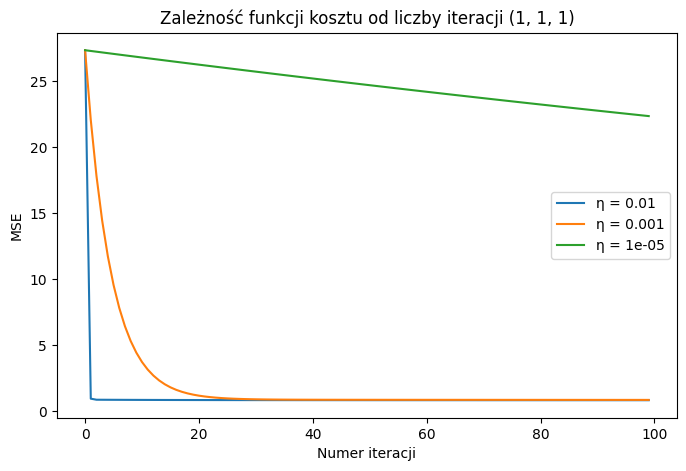

η = 0.01: końcowe wagi = (4.357523882806443, 15.368018640945731, -95.44877223790458), końcowy MSE = 338.8923
η = 0.001: końcowe wagi = (-61.853948192771355, 83.18196298524622, -98.36880058523764), końcowy MSE = 16705.2840
η = 1e-05: końcowe wagi = (-98.58878853824338, 100.75361826932097, -99.79681632241457), końcowy MSE = 41745.8382


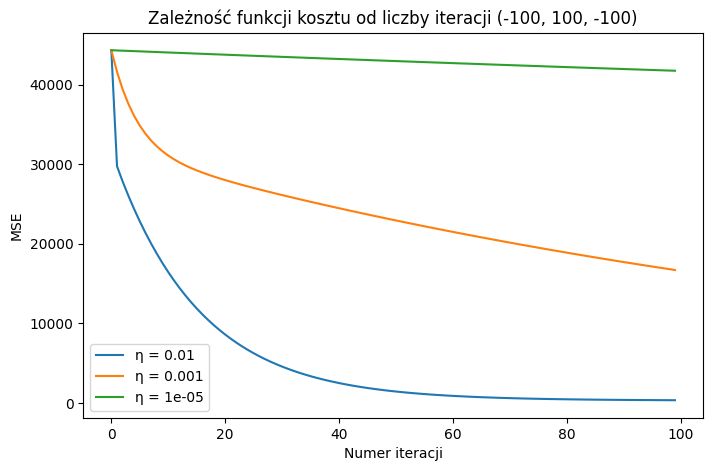

In [16]:
df = pd.read_csv("chipseq_expression_K562.txt")
X = df[["H3K27ac_signal", "H3K4me3_signal"]].values
t = df["expression"].values

def gradient_descent(w1, w2, w0, X, t, eta, iterations=100):
    losses = []
    for _ in range(iterations):
        loss = loss_function(w1, w2, w0, X, t)
        losses.append(loss)
        w1, w2, w0 = update_weights(w1, w2, w0, X, t, eta)
    return losses, (w1, w2, w0)


etas = [0.01, 0.001, 0.00001]
initial_params = (1, 1, 1)
results = {}

for eta in etas:
    losses, final_weights = gradient_descent(*initial_params, X, t, eta)
    results[eta] = (losses, final_weights)
    print(f"η = {eta}: końcowe wagi = {final_weights}, końcowy MSE = {losses[-1]:.4f}")


plt.figure(figsize=(8, 5))
for eta, (losses, _) in results.items():
    plt.plot(losses, label=f"η = {eta}")

plt.xlabel("Numer iteracji")
plt.ylabel("MSE")
plt.title("Zależność funkcji kosztu od liczby iteracji (1, 1, 1)")
plt.legend()
plt.show()

initial_params = (-100, 100, -100)
results = {}

for eta in etas:
    losses, final_weights = gradient_descent(*initial_params, X, t, eta)
    results[eta] = (losses, final_weights)
    print(f"η = {eta}: końcowe wagi = {final_weights}, końcowy MSE = {losses[-1]:.4f}")


plt.figure(figsize=(8, 5))
for eta, (losses, _) in results.items():
    plt.plot(losses, label=f"η = {eta}")

plt.xlabel("Numer iteracji")
plt.ylabel("MSE")
plt.title("Zależność funkcji kosztu od liczby iteracji (-100, 100, -100)")
plt.legend()
plt.show()

<h5> Podsumowanie:
    
 - szybkość zmniejszania się wartości funkcji kosztu zależy od parametrów początkowych i kroku eta 
    
 - im większe parametry początkowe np. (-100, 100, -100) tym dłużej zajmuje ich wyliczenie, tzn. dla przeprowadzonych 100 iteracji końcowy błąd jest większy (MSE = [338.8923, 16705.2840, 41745.8382] odpowiednio dla eta = [0.01, 0.001, 0.00001])
   
 - im mniejsze wartości początkowe (1, 1, 1) tym szybciej maleje funkcja kosztu do MSE = [0.8394, 0.8634, 22.3426].

 - dla η = 0.01 wyniki są najbardziej wiarygodne - błąd jest zdecydowanie najmniejszy

 - Wnioski: zbyt duże η może powodować niestabilność, a zbyt małe – bardzo wolne zbliżanie się do minimalnej wartości błędu. W naszym przypadku η = 0.01 daje najlepszy kompromis między szybkością a stabilnością uczenia.


<h4> Zadanie4: Zazwyczaj nie wiemy z góry ile razy należy zmodyfikować wagi - kiedy dalsza aktualizacja nie przynosi efektu. Jednym z rozwiązań tego problemu jest sprawdzenie o jaki procent zmieniają sie aktualne wagi. Przyjmijmy, że jeżeli zmiana funkcji kosztu jest mniejsza niż 0,1% to przerywamy działanie. Ile kroków należałoby wykonać aby zrealizować poprzednie zadanie (dla wybranego zestawu pozostałych hiperparametrów)?

Zatrzymano po 18 iteracjach (zmiana = 0.0967%)
η = 0.01: końcowe wagi = (0.45298502304624927, 0.5574527673656497, 0.8929628132947875), końcowy MSE = 0.8547
Zatrzymano po 42 iteracjach (zmiana = 0.0870%)
η = 0.001: końcowe wagi = (0.4911172532544675, 0.5263454900772214, 0.9024356069182801), końcowy MSE = 0.8748
Zatrzymano po 1665 iteracjach (zmiana = 0.1000%)
η = 1e-05: końcowe wagi = (0.5807426254436737, 0.5984866348781427, 0.9196312860513005), końcowy MSE = 1.6666


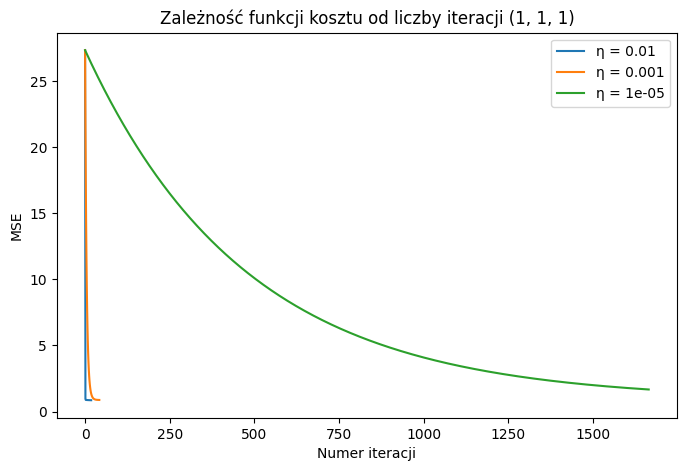

In [22]:
def gradient_descent(w1, w2, w0, X, t, eta, max_iter=10000):
    losses = []
    prev_loss = float('inf')
    i = 0

    while i < max_iter: #żeby zapobiec nieskończonej pętli
        loss = loss_function(w1, w2, w0, X, t)
        losses.append(loss)

        #procentowa zmiana
        if i > 0:
            rel_change = abs(losses[-2] - losses[-1]) / losses[-2]
            if rel_change < 0.001:
                print(f"Zatrzymano po {i} iteracjach (zmiana = {rel_change*100:.4f}%)")
                break

        w1, w2, w0 = update_weights(w1, w2, w0, X, t, eta)
        i += 1 #monitorowanie ilości iteracji

    return losses, (w1, w2, w0)


etas = [0.01, 0.001, 0.00001]
initial_params = (1, 1, 1)
results = {}

for eta in etas:
    losses, final_weights = gradient_descent(*initial_params, X, t, eta)
    results[eta] = (losses, final_weights)
    print(f"η = {eta}: końcowe wagi = {final_weights}, końcowy MSE = {losses[-1]:.4f}")


plt.figure(figsize=(8, 5))
for eta, (losses, _) in results.items():
    plt.plot(losses, label=f"η = {eta}")

plt.xlabel("Numer iteracji")
plt.ylabel("MSE")
plt.title("Zależność funkcji kosztu od liczby iteracji (1, 1, 1)")
plt.legend()
plt.show()

Odpowiedź: kilkanaście iteracji

In [24]:
model.coef_ #wspolczynnki dla zmiennych

array([0.48164297, 0.74793775])

In [25]:
model.intercept_ #wyraz wolny

np.float64(-0.23377574137486512)

<h4> Zadanie5: Porównaj te parametry z otrzymanymi z Zadania3. Skomentuj otrzymane wyniki.

| parametry | spadek gradientów (zadanie 3) | regresja liniowa (zadanie 5) |
| -------- | ------- | ---------- |
| w1 | 0.40293518222594205    | 0.48164297
| w2 | 0.6190552767990104     | 0.74793775
| w0 | 0.8376943804295451    | -0.23377574137486512


Parametry w1 i w2 wykazują duże podobieństwo przy obu metodach. Wyraz wolny bardziej różni się pomiędzy metodami. Różnice mogą wynikać z:
- nie do końca odpowiednio dobranego kroku eta
- zbyt krótkich obliczeń w przypadku spadku gradientów
- często błędy w dwóch pierwszych parametrów kumulują się w intercept \
Żródło: https://medium.com/data-science/gradient-descent-the-learning-rate-and-the-importance-of-feature-scaling-6c0b416596e1

<h4> Zadanie6: Rozważ jeszcze raz dane $d2/target$.
    
- Podziel je na trzy podzbiory - treningowy (60%), walidacyjny (20%) oraz testowy (20%); najlepiej przez odpowiednią funkcję.
- Przetestuj różne wartości parametrów $\eta$ na zbiorze walidacyjnym, na tej podstawie wybierz jeden, który użyjesz do wytrenowania parametrów modelu na zbiórze treningowym.
- Na końcu wyznacz wartość funkcji kosztu na zbiorze testowym. Skomentuj otrzymane wyniki.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("chipseq_expression_K562.txt")
X = df[["H3K27ac_signal", "H3K4me3_signal"]].values
t = df["expression"].values

#podział
X_train, X_temp, t_train, t_temp = train_test_split(X, t, test_size=0.4, random_state=42) #60
X_val, X_test, t_val, t_test = train_test_split(X_temp, t_temp, test_size=0.5, random_state=42) #20-20

etas = [0.0001, 0.001, 0.005, 0.01]
results = {}

for eta in etas:
    losses, (w1, w2, w0) = gradient_descent(1, 1, 1, X_val, t_val, eta)
    final_loss = losses[-1]
    print(f"Końcowe MSE dla eta={eta}: {final_loss:.6f}")

Końcowe MSE dla eta=0.0001: 3.944656
Końcowe MSE dla eta=0.001: 0.727222
Końcowe MSE dla eta=0.005: 0.687215
Końcowe MSE dla eta=0.01: 0.683178


Wniosek: najlepsze wartości MSE dla wartości 0.01. Gdy były testowane wyższe wartości pojawiał się błąd.

In [44]:
eta = 0.01
print(f"\nModel dla eta = {eta}")

#trening na zbiorze treningowym
losses, (w1, w2, w0) = gradient_descent(1, 1, 1, X_train, t_train, eta)
train_loss = losses[-1]

#MSE na zbiorze testowym
test_loss = loss_function(w1, w2, w0, X_test, t_test)

print(f"Końcowe wagi: w1={w1:.6f}, w2={w2:.6f}, w0={w0:.6f}")
print(f"MSE na zbiorze treningowym: {train_loss:.6f}")
print(f"MSE na zbiorze testowym:     {test_loss:.6f}")


Model dla eta = 0.01
Końcowe wagi: w1=0.435465, w2=0.608296, w0=0.839602
MSE na zbiorze treningowym: 0.800729
MSE na zbiorze testowym:     1.123987


Wyniki są spójne z poprawnym zachowaniem modelu regresji liniowej trenowanego metodą spadku gradientów. Różnica między błędem treningowym a testowym jest niewielka, co oznacza, że model dobrze się nauczył zależności między cechami a wartością docelową, nie ma wyraźnego przeuczenia (overfittingu) i wybrany η = 0.01 jest dobry — zapewnił szybkie i stabilne zbieganie do minimum.

Wyliczone wartości wag znaczą, że wpływ sygnału H3K4me3 (w2) na ekspresję genu jest nieco większy niż H3K27ac, ale obie zmienne mają dodatnią korelację z expression.

Ostateczna różnica pomiędzy zbiorem testowym a treningowym jest niewielka, co świadczy o poprawności wykonania modelu.